In [1]:
import os
import sys
import zarr
import numpy as np
import xarray as xr
from glob import glob

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

## Original data files

In [3]:
fn_init_boundary = sorted(glob('/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/*'))

In [4]:
fn_init = '/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/FE_interp_17UTC.0'
ds_init = xr.open_dataset(fn_init)

fn_boundary = '/glade/campaign/ral/wsap/ksha/FE_Cases/2018010100/ICBC/FE_Bndys.0'
ds_boundary = xr.open_dataset(fn_boundary)

* each case begins at 12:00:00 PM noon local time
* fasteddy runs on 0.01 sec per step on ending time, 3000 steps per output.
* the run begins with the 90000-th step (15 minutes), then outputs on every 0.5 min up to 59.5 min, 89 steps in total per case with the last step missing
* 60 boundary steps, each step is a minute begin with 12:00:00 (0, 1, 2, ..., 60 min)

In [5]:
fn_outputs = sorted(glob('/glade/derecho/scratch/casali/DigitalTwin/InputData/2018010100/output/*'))

In [6]:
fn_output = '/glade/derecho/scratch/casali/DigitalTwin/InputData/2018010100/output/FE_downtown.105000'
ds_output = xr.open_dataset(fn_output)

In [7]:
zpos = ds_output['zPos'].values

In [8]:
zmean = zpos[0, ...].max(axis=(1, 2))

In [9]:
zmean[[1, 4, 7, 10, 15, 20, 30, 40, 50]]

array([172.20572, 184.66513, 197.19846, 209.85495, 231.35663, 253.56541,
       301.01663, 354.0334 , 414.4404 ], dtype=float32)

## Prepared zarr files

In [3]:
filenames = glob('/glade/derecho/scratch/ksha/FastEddy/FE_04lev/experiment_*.zarr')

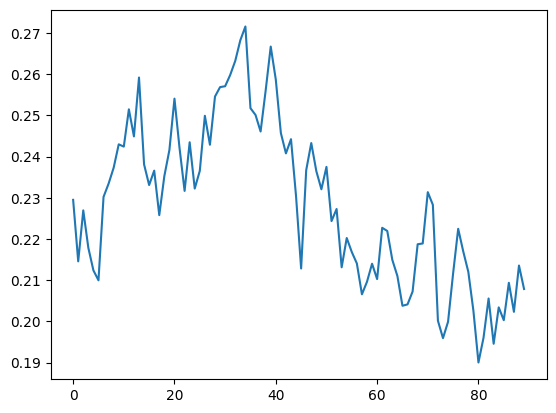

In [29]:
i = 0
ds = xr.open_zarr(filenames[i])

std_u = ds['u'].mean(['yIndex', 'xIndex']).values
plt.plot(std_u[:, 0])

In [16]:
u = ds['u'].values

In [17]:
u.shape

(90, 4, 592, 592)

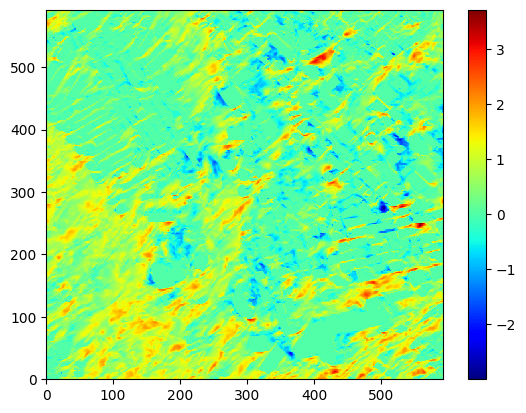

In [19]:
plt.pcolormesh(u[0, 0, ...], cmap=plt.cm.jet)
plt.colorbar()

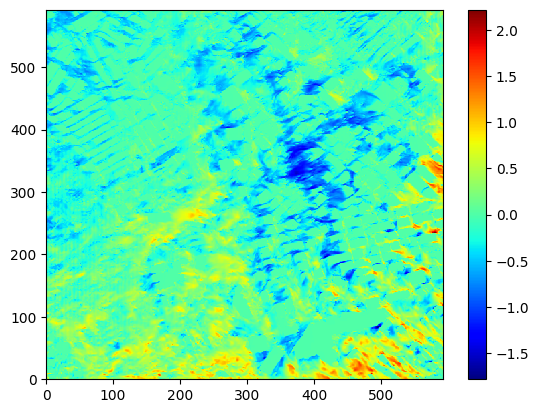

In [21]:
plt.pcolormesh(u[80, 0, ...], cmap=plt.cm.jet)
plt.colorbar()

## Comparisons with AI output

In [3]:
def subset_patch(
    ds: xr.Dataset,
    input_size,
    start,   # (ilat0, ilon0). If None → center crop
    lat_name = "yIndex",
    lon_name = "xIndex",
) -> xr.Dataset:
    """
    Return a spatial subset of shape (time, input_size[0], input_size[1]).
    Assumes ds has dims (time, lat, lon).
    """
    H = ds.dims[lat_name]
    W = ds.dims[lon_name]
    h, w = input_size

    if h > H or w > W:
        raise ValueError(f"Requested patch {h}x{w} exceeds dataset size {H}x{W}")

    if start is None:
        i0 = (H - h) // 2
        j0 = (W - w) // 2
    else:
        i0, j0 = start
        if i0 < 0 or j0 < 0 or i0 + h > H or j0 + w > W:
            raise ValueError(f"Start {(i0, j0)} with size {(h, w)} is out of bounds for {H}x{W}")

    i1 = i0 + h
    j1 = j0 + w

    return ds.isel({lat_name: slice(i0, i1), lon_name: slice(j0, j1)})

In [10]:
fn_target = '/glade/derecho/scratch/ksha/FastEddy/FE_04lev/experiment_10.zarr'
ds_target = xr.open_zarr(fn_target).isel(time=slice(1, None))
ds_sub = subset_patch(ds_target, input_size=(256, 256), start=None)
u_target = ds_sub['u'].values
v_target = ds_sub['v'].values
w_target = ds_sub['w'].values
rho_target = ds_sub['rho'].values
qv_target = ds_sub['qv'].values
theta_target = ds_sub['theta'].values

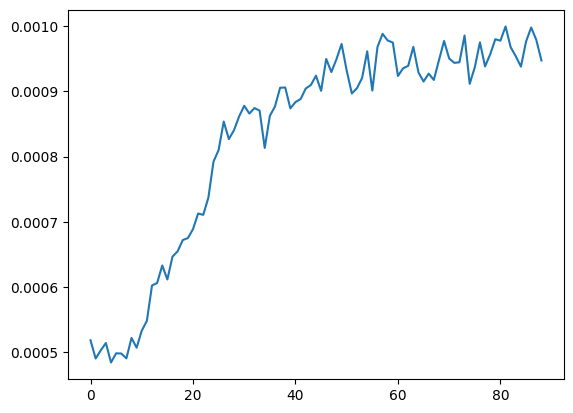

In [16]:
plt.plot(rho_target.std(axis=(2, 3))[:, 3])

In [5]:
fn_list = sorted(glob('/glade/derecho/scratch/ksha/DWC/RAW_OUTPUT/FE_large_test/2018-01-31T121500/pred_*.nc'))
ds_collect = []
for fn in fn_list:
    ds_collect.append(xr.open_dataset(fn))

ds_fcst = xr.concat(ds_collect, dim='time')
u_fcst = ds_fcst['u'].values
v_fcst = ds_fcst['v'].values
w_fcst = ds_fcst['w'].values
rho_fcst = ds_fcst['rho'].values
qv_fcst = ds_fcst['qv'].values
theta_fcst = ds_fcst['theta'].values

In [13]:
rho_fcst.min()

1.1668576

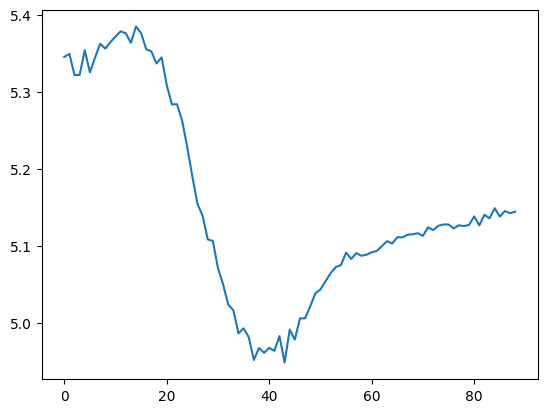

In [6]:
plt.plot(u_fcst.mean(axis=(2, 3))[:, 3])

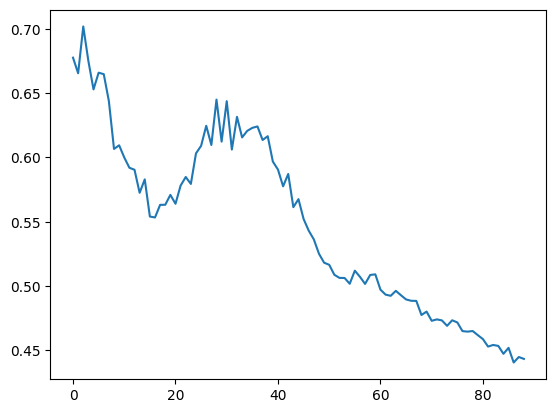

In [42]:
plt.plot(u_fcst.std(axis=(2, 3))[:, 3])

In [31]:
u_fcst.shape

(89, 4, 256, 256)